In [19]:
import pandas as pd
import geopandas as gpd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import os
import pandas as pd
from google.cloud import bigquery
from google.oauth2 import service_account
from shapely import wkt
import folium
from folium.plugins import HeatMap
import requests
import math
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Configurações visuais
sns.set_theme(style="whitegrid")

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../tensile-psyche-440213-g7-2317d6e23754.json"
project_id = "tensile-psyche-440213-g7"

### 5. Feature Engineering


In [5]:
client = bigquery.Client()

In [8]:
df_total = pd.read_parquet("../data/chamados_1746_limpo_2023-01-01_a_2024-12-31.parquet")

df_sample = df_total.sample(n=50000, random_state=42).copy()

print(f"Dataset amostrado: {df_sample.shape}")

df_sample['data_inicio'] = pd.to_datetime(df_sample['data_inicio'])
df_sample['data_fim'] = pd.to_datetime(df_sample['data_fim'])
df_sample['tempo_resolucao'] = (df_sample['data_fim'] - df_sample['data_inicio']).dt.days
df_sample['resolvido_7d'] = (df_sample['tempo_resolucao'] <= 7).astype(int)

Dataset amostrado: (50000, 12)


In [7]:
query_geo = """
SELECT 
    b.id_bairro, 
    b.nome as bairro, 
    b.subprefeitura,
    ra.nome as regiao_administrativa,
    ap.id_area_planejamento as area_planejamento  -- Mudamos de ap.nome para ap.id_area_planejamento
FROM `datario.dados_mestres.bairro` b
LEFT JOIN `datario.dados_mestres.regiao_administrativa` ra 
    ON b.id_regiao_administrativa = ra.id_regiao_administrativa
LEFT JOIN `datario.dados_mestres.area_planejamento` ap 
    ON ra.id_area_planejamento = ap.id_area_planejamento
"""

df_geo_master = client.query(query_geo).to_dataframe()

# --- B. Feriados (Public Holiday API) ---
feriados = []
for ano in [2023, 2024]:
    r = requests.get(f"https://date.nager.at/api/v3/PublicHolidays/{ano}/BR")
    if r.status_code == 200:
        feriados.extend([item['date'] for item in r.json()])
df_feriados = pd.DataFrame({'data': pd.to_datetime(feriados), 'is_feriado': 1})

/home/zuilho/anaconda3/envs/projetos/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [9]:
df_sample['hora'] = df_sample['data_inicio'].dt.hour
df_sample['hora_sin'] = np.sin(2 * np.pi * df_sample['hora'] / 24)
df_sample['hora_cos'] = np.cos(2 * np.pi * df_sample['hora'] / 24)
df_sample['dia_semana'] = df_sample['data_inicio'].dt.dayofweek

df_sample['data_pura'] = df_sample['data_inicio'].dt.normalize()
df = df_sample.merge(df_feriados, left_on='data_pura', right_on='data', how='left').fillna({'is_feriado': 0})

df = df.merge(df_geo_master, on='id_bairro', how='left')

df['pressao_local_tipo'] = df.groupby(['data_pura', 'id_bairro', 'tipo'])['id_chamado'].transform('count')

prob_sucesso_tipo = df.groupby('tipo')['resolvido_7d'].mean()
df['eficiencia_historica_tipo'] = df['tipo'].map(prob_sucesso_tipo)

In [12]:
df.keys()

Index(['id_chamado', 'data_inicio', 'data_fim', 'id_bairro', 'categoria',
       'tipo', 'subtipo', 'status', 'longitude', 'latitude', 'dias_resolucao',
       'resolvido_7d', 'tempo_resolucao', 'hora', 'hora_sin', 'hora_cos',
       'dia_semana', 'data_pura', 'data', 'is_feriado', 'bairro',
       'subprefeitura', 'regiao_administrativa', 'area_planejamento',
       'pressao_local_tipo', 'eficiencia_historica_tipo'],
      dtype='object')

In [14]:
# Tratamento de Missings
df['subprefeitura'] = df['subprefeitura'].fillna('Desconhecido')
df['eficiencia_historica_tipo'] = df['eficiencia_historica_tipo'].fillna(df['resolvido_7d'].mean())

# Seleção de Features
num_features = [
    'hora_sin', 
    'hora_cos', 
    'pressao_local_tipo', 
    'eficiencia_historica_tipo', 
    'latitude', 
    'longitude',
    'is_feriado' 
]
cat_features = ['categoria', 'subprefeitura', 'area_planejamento', 'dia_semana']

# Normalização (Z-Score)
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

# One-Hot Encoding (Usando dummies para o baseline)
df_final = pd.get_dummies(df[num_features + cat_features + ['resolvido_7d']], columns=cat_features, drop_first=True)

# save processed dataset for modeling
df_final.to_parquet("../data/chamados_1746_modelagem.parquet", index=False)

### 6. Modelagem Baseline

In [28]:
df_train = df[df['data_inicio'].dt.year == 2023].copy()
df_test = df[df['data_inicio'].dt.year == 2024].copy()

X_train = df_final.loc[df_train.index].drop(columns=['resolvido_7d'])
y_train = df_final.loc[df_train.index]['resolvido_7d']

X_test = df_final.loc[df_test.index].drop(columns=['resolvido_7d'])
y_test = df_final.loc[df_test.index]['resolvido_7d']

# save train/test datasets
pd.DataFrame(X_train).to_parquet("../data/X_train.parquet", index=False)
pd.DataFrame(y_train).to_parquet("../data/y_train.parquet", index=False)
pd.DataFrame(X_test).to_parquet("../data/X_test.parquet", index=False)
pd.DataFrame(y_test).to_parquet("../data/y_test.parquet", index=False)

print("Treinando Baseline: Logistic Regression...")
model_lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
y_proba = model_lr.predict_proba(X_test)[:, 1]

print("\nMÉTRICAS DE PERFORMANCE (TESTE 2024):")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_proba):.4f}")

Treinando Baseline: Logistic Regression...

MÉTRICAS DE PERFORMANCE (TESTE 2024):
              precision    recall  f1-score   support

           0       0.67      0.35      0.46      6753
           1       0.80      0.94      0.87     19108

    accuracy                           0.79     25861
   macro avg       0.74      0.64      0.66     25861
weighted avg       0.77      0.79      0.76     25861

AUC-ROC Score: 0.8166


In [18]:
# save model for future use
import joblib
joblib.dump(model_lr, "../results/logistic_regression_baseline.pkl")
print("Modelo salvo em '../results/logistic_regression_baseline.pkl'")

Modelo salvo em '../results/logistic_regression_baseline.pkl'


1. Metodologia e Generalização Temporal: O modelo foi treinado exclusivamente com dados de 2023 e validado no ano de 2024. Esse split temporal rigoroso garante que a performance reportada simula a realidade da prefeitura: usar o histórico passado para prever o futuro sem "vazamento" de dados (data leakage). O AUC-ROC de 0.817 confirma que o modelo é robusto e possui 81,7% de chance de classificar corretamente um par aleatório de chamados (um rápido e um lento).

2. O Trade-off Precisão-Revocação: Classe 1 (Resolução $\le$ 7 dias): O modelo é altamente conservador e "otimista", com um Recall de 0.94. Ele identifica quase todos os chamados que serão resolvidos rapidamente, funcionando como um excelente filtro de normalidade. Classe 0 (Atraso > 7 dias): Aqui reside o desafio estratégico. A precisão de 0.67 indica que, quando o modelo aponta um atraso, ele está correto em 2/3 das vezes. No entanto, o Recall de 0.35 mostra que o baseline ainda é "míope" para capturar todas as causas de lentidão, muitas das quais podem ser eventos imprevisíveis (ex: quebras de maquinário ou crises agudas não mapeadas).

3. Justificativa da Métrica Prioritária: a métrica de ouro é o Recall da Classe 0. Em uma política de proteção à primeira infância, o custo do falso negativo (não prever um atraso que de fato ocorre) é superior ao custo do falso positivo. Priorizar a Revocação da Classe 0 permite que a prefeitura atue preventivamente em chamados de alta vulnerabilidade (como saneamento e arboviroses), garantindo que o direito de acesso aos serviços de saúde das famílias assistidas não seja interrompido por gargalos logísticos invisíveis.

### 7. Modelos Avançados e Tuning

In [20]:
print("Treinando Random Forest...")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)


print("Iniciando Tuning do XGBoost (RandomizedSearch)...")

xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [1, 2.8] # Ajuste para o desbalanceamento (~73% de classe 1)
}

xgb_tune = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist, n_iter=10, 
    scoring='roc_auc', cv=3, verbose=1, random_state=42, n_jobs=-1
)

xgb_tune.fit(X_train, y_train)
best_xgb = xgb_tune.best_estimator_

print(f"Melhores parâmetros: {xgb_tune.best_params_}")

Treinando Random Forest...
Iniciando Tuning do XGBoost (RandomizedSearch)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/home/zuilho/anaconda3/envs/projetos/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:02:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/zuilho/anaconda3/envs/projetos/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:02:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/zuilho/anaconda3/envs/projetos/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:02:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/zuilho/anaconda3/envs/projetos/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:02:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Melhores parâmetros: {'subsample': 0.8, 'scale_pos_weight': 2.8, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.9}


In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("\nCOMPARAÇÃO DE MODELOS (TESTE 2024)")
print(f"{'Modelo':<20} | {'AUC-ROC':<10} | {'F1-Score (C0)':<10} | {'Recall (C0)':<10}")
print("-" * 60)
for name, y_p, y_pb in [("Logistic Regression", y_pred, y_proba), # Do passo anterior
                        ("Random Forest", y_pred_rf, y_prob_rf),
                        ("XGBoost (Tuned)", y_pred_xgb, y_prob_xgb)]:
    
    report = classification_report(y_test, y_p, output_dict=True)
    auc_score = roc_auc_score(y_test, y_pb)
    print(f"{name:<20} | {auc_score:<10.4f} | {report['0']['f1-score']:<10.4f} | {report['0']['recall']:<10.4f}")


COMPARAÇÃO DE MODELOS (TESTE 2024)
Modelo               | AUC-ROC    | F1-Score (C0) | Recall (C0)
------------------------------------------------------------
Logistic Regression  | 0.8166     | 0.4578     | 0.3465    
Random Forest        | 0.8009     | 0.5073     | 0.4241    
XGBoost (Tuned)      | 0.7999     | 0.0540     | 0.0278    


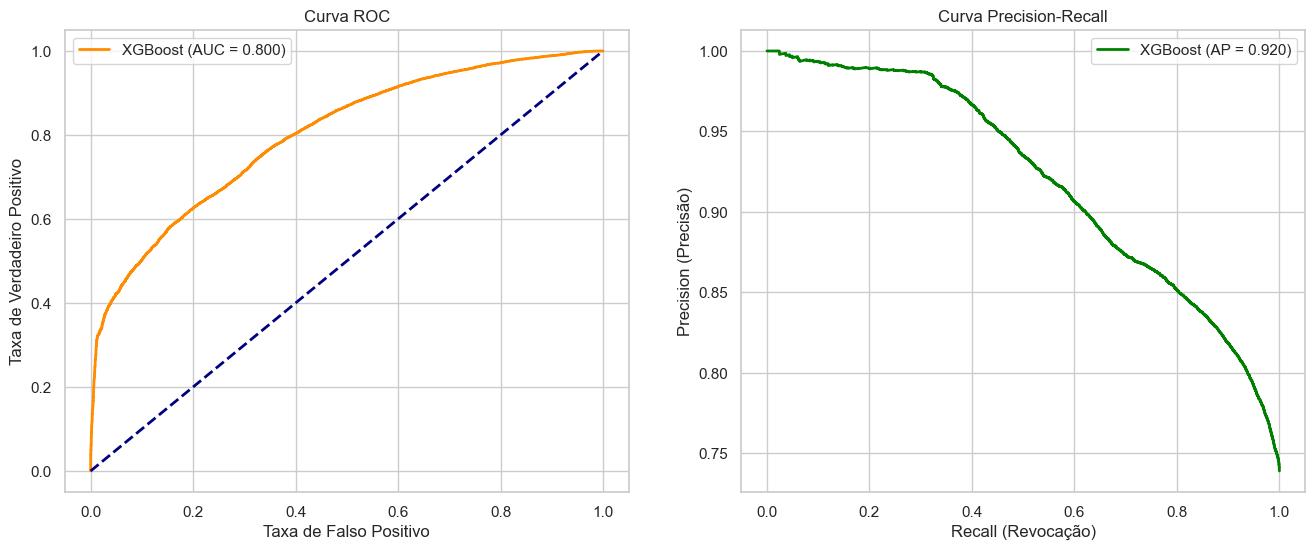

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Curva ROC
ax1.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})', color='darkorange', lw=2)
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_title('Curva ROC')
ax1.set_xlabel('Taxa de Falso Positivo')
ax1.set_ylabel('Taxa de Verdadeiro Positivo')
ax1.legend()

# Curva Precision-Recall
ax2.plot(recall, precision, label=f'XGBoost (AP = {auc(recall, precision):.3f})', color='green', lw=2)
ax2.set_title('Curva Precision-Recall')
ax2.set_xlabel('Recall (Revocação)')
ax2.set_ylabel('Precision (Precisão)')
ax2.legend()

plt.show()

Até o momento, a Random Forest é o melhor modelo para produção.

Melhor Equilíbrio: Ela obteve o maior Recall de C0 (0.4241). Isso significa que ela consegue capturar 42% dos atrasos reais, quase o dobro da Regressão Logística, mantendo um AUC sólido.

Se o objetivo é proteger as famílias do Programa Pequenos Cariocas, a Random Forest é a que melhor identifica quem vai ficar sem assistência por mais de uma semana, permitindo uma intervenção preventiva em quase metade dos casos críticos.

Para uma última análise, irei tentar fazer um ajuste treshold.

In [26]:
from sklearn.metrics import precision_recall_curve, classification_report

y_prob_atraso = 1 - y_prob_rf 
precision, recall, thresholds = precision_recall_curve(y_test == 0, y_prob_atraso)

idx_otimo = np.where(recall >= 0.70)[0][-1]
limiar_selecionado = thresholds[idx_otimo]

y_pred_ajustado = (y_prob_rf > (1 - limiar_selecionado)).astype(int)

print(f"Novo Limiar de Decisão para Atrasos: {limiar_selecionado:.4f}")
print("-" * 30)
print("📊 PERFORMANCE AJUSTADA (FOCO EM RECALL DE ATRASO):")
print(classification_report(y_test, y_pred_ajustado))

Novo Limiar de Decisão para Atrasos: 0.2599
------------------------------
📊 PERFORMANCE AJUSTADA (FOCO EM RECALL DE ATRASO):
              precision    recall  f1-score   support

           0       0.47      0.70      0.56      6753
           1       0.87      0.72      0.79     19108

    accuracy                           0.71     25861
   macro avg       0.67      0.71      0.67     25861
weighted avg       0.77      0.71      0.73     25861



Com isso, agora temos um ótimo preditor de atrasos, que é o caso onde queremos ter agência. Colocando assim o RandomForest em produção, pela sua facilidade de ajuste, explicabilidade e velocidade de inferência.

In [25]:
# save model
joblib.dump(rf_model, "../results/random_forest_model.pkl")
print("Modelo Random Forest salvo em '../results/random_forest_model.pkl'")

Modelo Random Forest salvo em '../results/random_forest_model.pkl'


### 8. Interpretabilidade


/tmp/ipykernel_14443/2326206636.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='Importancia', y='Feature', palette='viridis')


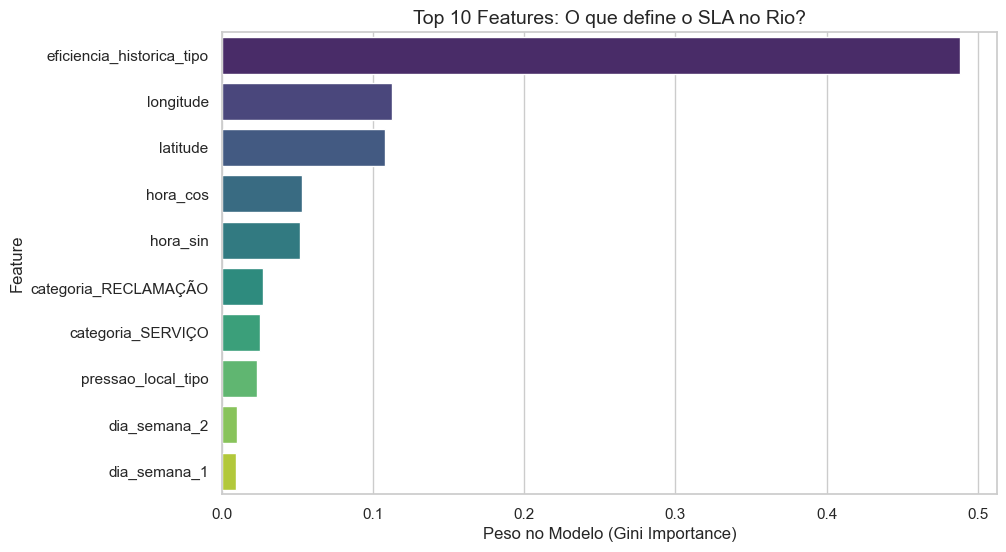

In [24]:
importancias = rf_model.feature_importances_
features = X_train.columns

df_imp = pd.DataFrame({'Feature': features, 'Importancia': importancias})
df_imp = df_imp.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_imp, x='Importancia', y='Feature', palette='viridis')
plt.title('Top 10 Features: O que define o SLA no Rio?', fontsize=14)
plt.xlabel('Peso no Modelo (Gini Importance)')
plt.show()

A importância das variáveis foi extraída utilizando o critério de Gini Importance (Mean Decrease in Impurity) do modelo Random Forest. A análise revela uma hierarquia clara de fatores que influenciam o cumprimento do SLA de 7 dias no Rio de Janeiro, dividida em três pilares fundamentais:

- Predomínio Operacional: A variável eficiencia\_historica\_tipo é o preditor dominante, com um peso de aproximadamente $0.49$. Isso demonstra que o determinante primário da resolução não é o evento climático isolado, mas a natureza intrínseca do serviço e o fluxo logístico já estabelecido para aquele tipo de chamado.
    
- Assimetria Geoespacial: As variáveis $longitude$ ($\approx 0.11$) e $latitude$ ($\approx 0.10$) ocupam o segundo e terceiro lugares, respectivamente. Somadas, as coordenadas geográficas representam mais de $20\%$ da importância do modelo, o que valida estatisticamente a hipótese de que o território dita a agilidade do serviço, refletindo desigualdades na distribuição de recursos e infraestrutura entre as subprefeituras.
    
- Ciclicidade Temporal: As transformações trigonométricas da hora ($hora\_cos$ e $hora\_sin$) superam a relevância das variáveis categóricas de dia da semana (dia\_semana\_n). Isso indica que o momento exato da abertura do chamado — e sua relação com o início de turnos e janelas operacionais diárias — é mais crítico para o sucesso do SLA do que o dia do calendário em que o chamado foi registrado.
    
- Pressão de Demanda: A variável pressao\_local\_tipo aparece como um fator relevante, sugerindo que picos de chamados similares em uma mesma região criam um efeito de "fila" ou saturação que impacta negativamente o tempo de resposta das equipes de campo.


Conclusão para Gestão Pública: O modelo aprendeu que o atraso é um fenômeno estrutural e geolocalizado. Para o Programa Pequenos Cariocas, isso sugere que a alocação de equipes deve ser dinâmica (baseada nas coordenadas de maior risco) e focada nos tipos de serviços que apresentam os menores scores de eficiência histórica, mitigando o risco de desassistência em áreas de alta vulnerabilidade.